# RL Car Racing

The project tackles the challenge of training a Reinforcement Learning agent to drive a **Formula 1 car** over **racing circuits**.

This file describes the formalization of the task, including the racing track and the corresponding MDP.

## A) Environment and Simulation

### Racing Track

A track is stored as a **lookup table** and indexed as points sampled at equal curved distance $\Delta s_{gen}$ along the track:
$$ \texttt{table}[i] = (s_i, x_i, y_i, \psi_i, \kappa_i) $$

The stored values are:
* $s_i$ = $i \cdot \Delta s_{gen}$ is the total distance to drive to the $i$-th sampled point from the (generated) start.
* $(x_i, y_i)$ is the **2D-coordinates** that the track passes through after a distance of $s_i$.
* $\psi_i$ is the **heading**, representing the direction the track is pointing at at the given location $(x_i, y_i)$.
* $\kappa_i$ is the **local curvature**, representing the way the track curves around the given location.

All tracks considered for the task are automatically generated. The generation first draws a closed polygon, in the shape of a **star**, and then perturbs the vertices and rounds the corners with circular arcs of different radii. It places a canonical start of the track in the middle of the longest generated straight.
Here are some examples of generated tracks:

<img src="docs/figures/presentation/generated_tracks.png" alt="Three generated circuits with boundaries, centerlines and start/finish gates" width="1200"> 


### Simulation Details

The simulation models time in seconds. 
Every $\Delta_{t_{phys}} = 0.01s$, the state of the agent is recomputed according to its current controls and the environments checks for any collision with obstacles.

The decision rate of the agent is set to $\Delta_{t_{agent}} = 0.04s$, meaning that the agent effectively interacts with the environment $25$ times per second. 
In other words, the agent only reacts every $4$ simulation steps, choosing the action to perform for the next $4$. 

> Note that the value of $\Delta_{t_{agent}}$ conditions the minimum number of steps needed to finish a lap of a circuit, and therefore the value for the effective horizon $T_{\max}$.

<img src="docs/figures/presentation/racing_simulation.png" alt="Broadcast visualization of the reference controller driving the saved circuit" width="600"> 


### Environment Representations

The environment is fully represented by:
$$ s_t = (x_t, y_t, \theta_t, v_t, \delta_t, C, \ell_t) \in S$$

Where:
* $x_t, y_t, \theta_t$ describe the **current pose** of the car (location and orientation).
* $v_t, \delta_t$ describe the **current internal state** of the car (velocity and front-wheel angle).
* $C$ is the **configuration of the circuit**, representing the environment as described above.
* $\ell_t$ is the **episode lifecycle state**: elapsed agent steps; the moving start/finish reference; accumulated signed progress; and the recent progress history used to detect stalling.

This is the complete environment state, but it is not what the agents observe.

> Note that $v_t$ and $\delta_t$ are part of the environment because they do not correspond *directly* to the controls of the agent. In fact, the agent controls acceleration and steering, but the actual velocity and heading are subject to physical forces.


#### Observed State 1: Frenet Coordinates

Frenet coordinates provide a track-relative observation. They assume that the car can localize itself on the track and has access to local circuit geometry.

$$ O_t^{\text{Frenet}} = (d_t, \phi_{e,t}, v_t, \delta_t, \bar{\kappa}_t) \in S_{\text{Frenet}}$$

Where:
* $d_t$ is the lateral distance from the centerline of the track.
* $\phi_{e,t}$ is the heading error. That is, the discrepancy between car heading and track heading.
* $v_t$ is the current velocity.
* $\delta_t$ is the current front-wheel steering angle.
* $\bar{\kappa}_t$ is a velocity-dependent summary of the track curvature ahead.

> This is a partial observation of the full state. It omits the lifecycle state, and its local curvature summary does not identify an entire circuit. It is intended to expose useful short-horizon geometry.

#### Observed State 2: LiDAR Readings

A lower-level observation is given by the **LiDAR Readings**.
This observation assumes that the car does not know the full circuit, and can only use a LiDAR rangefinder sensor to observe the track around itself.

$$ O_t^{\text{LiDAR}} = (v_t, \delta_t, R) \in S_{\text{LiDAR}} $$

Where:
* $v_t$ describes current velocity.
* $\delta_t$ describes current front-wheel steering angle.
* $R$ represents the LiDAR ranges, divided by the maximum range of $100m$.

More precisely, we choose to model a LiDAR sensor with $16$ rays whose first and last rays are included in a field of view (FOV) of $200°$.
This corresponds to an angular separation of $200°/(16-1) \approx 13.33°$. 

> LiDAR is also a partial observation of the full state. Its local ranges omit the lifecycle state and the unobserved circuit beyond sensor range.



### Action Space

The agent interacts with the environment via control actions $a_t$:

$$ a_t = (a_t^{throttle}, a_t^{steer}) \in A=[-1,1]^2$$

Where:
* $a_t^{throttle}$ represents acceleration ($a_t^{throttle}>0$) or braking ($a_t^{throttle}<0$).
* $a_t^{steer}$ represents steering, from left ($a_t^{steer}>0$) to right ($a_t^{steer}<0$).

These are normalized actions, which are mapped to physical controls as:

$$
\bar{a}_t^{throttle} =
\begin{cases}
a_{max}\cdot a_t^{throttle}, & a_t^{throttle} \ge 0,\\
b_{max}\cdot a_t^{throttle}, & a_t^{throttle} < 0,
\end{cases}
\qquad
\bar{\delta}_t = \delta_{max} \cdot a_t^{steer}
$$

where:
* $a_{max} = 9.26 m/s^2$ is the engine-limited forward acceleration (approximately $0-100km/h$ in $3s$, before accounting for drag).
* $b_{max} = 20 m/s^2$ is the grip-limited braking deceleration.
* $\delta_{max} = 30°$ is the maximum steering angle.

Acceleration and braking differ, as with real cars: acceleration is limited by the engine, while braking is limited only by tires.
The effects of these physical controls are not straightforward.
More on this is specified below.

> Note that reversing is not allowed, as assumed not necessary in an F1 circuit.

### Transition Kernel

Given the current physical substate $(x_t, y_t, \theta_t, v_t, \delta_t, C)$ and a **normalized control action** $(\bar a_t^{throttle}, \bar\delta_t)$ as defined above. 
The physical transition is expressed by the **bicycle model** equations:

$$
\begin{aligned}
    \dot{x} = v_t \cos(\theta_t) \quad &x_{t+1} = x_{t} + \Delta_t \dot{x} \\
    \dot{y} = v_t \sin(\theta_t) \quad &y_{t+1} = y_{t} + \Delta_t \dot{y} \\
    \dot{\delta} = \operatorname{clip}\left(\dfrac{\bar\delta_t - \delta_t}{\Delta_t}, -\dot{\delta}_{max}, +\dot{\delta}_{max}\right) \quad &\delta_{t+1} = \delta_t + \Delta_t\dot{\delta} \\
    \dot{\theta} = \frac{v_t}{L} \tan(\tilde{\delta}_{t+1}) \quad &\theta_{t+1} = \theta_{t} + \Delta_t \dot{\theta} \\
    \dot{v} = \bar{a}_t^{throttle} - c_d v_t^2 \quad &v_{t+1} = v_{t} + \Delta_t \dot{v}
\end{aligned}
$$

These equations are applied at each physics substep, with $\Delta_t=0.01s$. Here $L = 3.6m$ is the wheelbase, $\dot{\delta}_{max}$ is the maximum steering rate, and $\tilde{\delta}_{t+1}$ is derived from $\delta_{t+1}$ through tire friction constraints.

Some additional constraints are:
* Since reversing is not allowed, enforce $v_{t+1} \ge 0$.
* Also enforce $v_{t+1} \le v_{max}$, with $v_{max} = 70 m/s$ (around $250km/h$).

The environment models the effects of the physical control action according to three physical principles:
* **Aerodynamic Drag**, opposing motion at all times by reducing the acceleration desired by the car. The idea is to model $v_{max}$ as a physical limitation: when the air drag cancels full throttle.
* **Steering Rate Limit**, which eliminates the possibility to turn the steering wheel at a higher rate than $\dot\delta_{max} = 180°/s$.
* **Tire friction**, deciding whether the wheels' orientation matches the actual direction taken by the car. At higher speeds, the car won't follow the wheels and understeer.

#### Terminal and Initial States

##### Terminal States 

A state $s_t$ is `terminal` if:
* $s_t \in \mathcal{F}$. That is, the car crosses its finish gate forward after approximately one full lap. Or,
* $s_t \in \mathcal{W}$. That is, the point representing the car has reached or crossed a track boundary. Or,
* $s_t \in \mathcal{S}$. That is, the car has stopped racing and is simply stalling.

Finishing, crashing and stalling set `terminated=True`.
Reaching $T_{\max}$ without any of them sets `truncated=True`.

> Note that a stalled episode is still charged a negative reward for the entire time that it would have spent idling to the limit.
> In other words, this is more of a simulation shortcut than an actual modeling choice.

##### Initial States

**Training**. The start pose in training is sampled uniformly over the circuit:
$$
s_0 \sim \left(
  s^{arc} \sim \mathcal{U}[0, L_{track}),\;
  d_0 \sim \mathcal{U}[-0.5\tfrac{W}{2}, 0.5\tfrac{W}{2}],\;
  \phi_{e,0} \sim \mathcal{U}[-0.2, 0.2],\;
  v_0 \sim \mathcal{U}[0, 0.15\,v_{max}],\;
  \delta_0 = 0
\right)
$$

The finish gate moves with the start, so a lap is always one full circuit from wherever the car was placed.

> A fixed zero-speed start makes successful launch a prerequisite for collecting experience from the remainder of the circuit.
> This could be an issue if the agent ends up (or starts) in a spot where the throttle is non-positive: the car won't move ($v=0$) and the agent won't explore any other part of the circuit.
> Sampling the pose mitigates this. 

**Evaluation**. Deterministic evaluation always launches from the canonical start line with $v_0 = 0$:
$$ (x_0,y_0,\theta_0,v_0,\delta_0)=(x_{\mathrm{start}},y_{\mathrm{start}},\psi_{\mathrm{start}},0,0) $$

## Reward Function

The reward function for the MDP is the following:

$$
r_t(s_t, s_{t+1}) =
\begin{cases}
-R_{\text{crash}} & \text{if } s_{t+1} \in \mathcal{W} \\
R_{\text{finish}} + R_{\text{lap}}\left(1 - \dfrac{t+1}{T_{\max}}\right) & \text{if } s_{t+1} \in \mathcal{F} \\
-c_{\text{step}}\left(T_{\max} - t\right) & \text{if } s_{t+1} \in \mathcal{S} \\
-c_{\text{step}} + c_{\text{prog}} \cdot \Delta\tilde{s}_t & \text{otherwise}
\end{cases}
$$

Here $t=0,\ldots,T_{\max}-1$ indexes actions, so the elapsed action count after this transition is $t+1$.

Where:
* $R_{\text{finish}} = 100$
* $R_{\text{lap}} = 140$ is the completion reward, scaled by lap time.
* $R_{\text{crash}} = 5$
* $c_{\text{step}}= \rho \cdot \Delta_{t_{agent}} = 0.04$, with $\rho = 1s^{-1}$ representing the cost over one agent step.
* $c_{\text{prog}}=100$
* $\Delta \tilde{s}_t$ is the progress term, computed as a normalized difference between the current and next locations (see [`TRACK.md`](docs/TRACK.md)).

### Choosing the coefficients

The coefficients were chosen to satisfy three reward-design criteria.

1. **Trying must beat doing nothing.** A policy that stalls throughout the entirety of the episode (that is, for $T_{\max}$ steps) should be punished harder than one that crashes, even one that crashes immediately. The requirement is:
  $$ R_{\text{crash}} < c_{\text{step}} \cdot T_{\max}, $$

2. **Reaching further must be measurably better.** The progress term rewards distance covered before a crash, while the time cost penalizes delay. Its scale should be large relative to the crash penalty:
  $$ c_{\text{prog}} \gg R_{\text{crash}}, $$

3. **A fast lap must beat a slow lap by a visible margin.** If the goal is racing, the car should not just be incentivized for progressing, but also for finishing fast. Increasing $\rho$ too far can favour instant crashing over a slow lap. The solution is to add a proper bonus $R_{\text{lap}}$, that scales with the unused episode clock:

  $$ \frac{r(\text{fast lap}) - r(\text{slow lap})}{r(\text{fast lap})} > 0.2, $$

With the values specified above, all 3 conditions are satisfied:
1. $5 < 40$
2. $100 \gg 5$
3. Considering $T_{\max}=1000$, a deterministic reference controller takes at best $22s$ to finish a lap (empirically, over a set of random circuits). Assuming a slow lap to take $1.5 \times$ that, a slow lap takes $33s$. Condition 3 then solves as:
$$
r_{\text{fast}}
= R_{\text{finish}} + R_{\text{lap}}\left(1-\frac{22}{40}\right) - 22
= 100 + 140(1-0.55)-22
= 141,\\
r_{\text{slow}}
= R_{\text{finish}} + R_{\text{lap}}\left(1-\frac{33}{40}\right) - 33
= 100 + 140(1-0.825)-33
= 91.5,\\
r_{\text{fast,total}} \approx 141 + 100 = 241,\\
r_{\text{slow,total}} \approx 91.5 + 100 = 191.5,\\
\frac{r_{\text{fast,total}}-r_{\text{slow,total}}}{r_{\text{fast,total}}}
= \frac{241-191.5}{241}
\approx 0.205 > 0.2.
$$

Both successful laps accumulate approximately 100 points from the progress term. The implementation replaces the final steps shaping reward with the terminal reward; the calculation above is an illustration of the implemented coefficients.


### Horizon

The experimental setting has a finite horizon.
To align with this decision, no discount factor $\gamma$ is applied:
$$ \gamma = 1 $$

A different choice for $\gamma$ would place more weight on earlier rewards and would therefore define a different objective. The undiscounted choice keeps the reported objective aligned with the finite episode return.




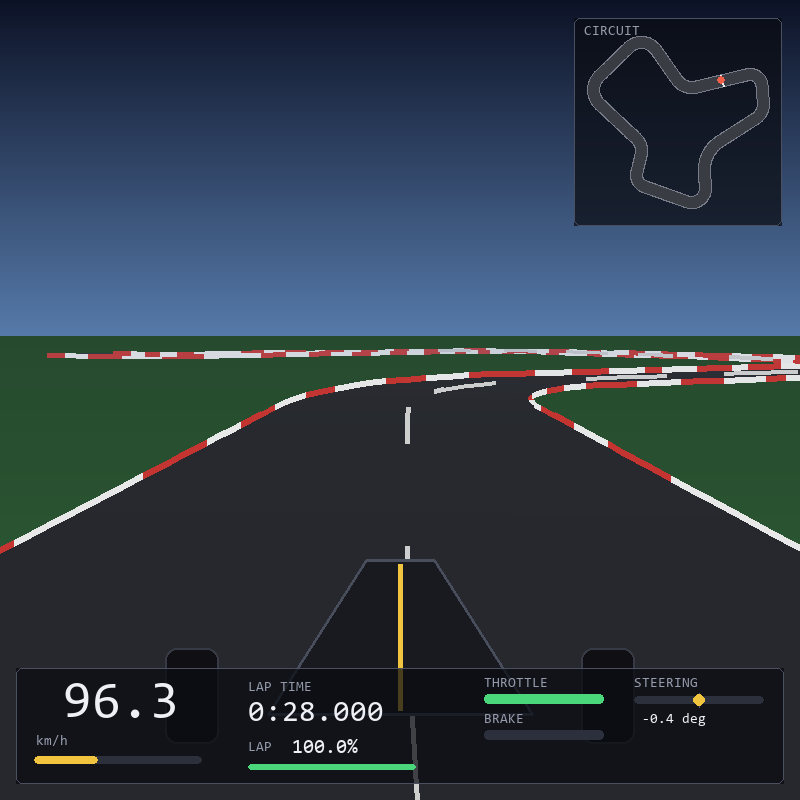

Completed: True | Time: 28.00 s


In [1]:
from time import sleep

from IPython.display import display
from PIL import Image

from agents.models import ScriptedFrenetPolicy
from configs import EnvironmentConfig, StartStateConfig
from envs import RacingEnv, TrackWithGeometry

seed = 0
track = TrackWithGeometry.load("tracks/experiment_1.json")
config = EnvironmentConfig(start=StartStateConfig(randomized=False))
env = RacingEnv(track, config=config, render_mode="rgb_array")
controller = ScriptedFrenetPolicy()
observation, _ = env.reset(seed=seed)
viewer = display(Image.fromarray(env.render()), display_id=True)

try:
    for step in range(config.simulation.max_episode_steps):
        action = controller.action(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        if step % 2 == 0 or terminated or truncated:
            viewer.update(Image.fromarray(env.render()))
            sleep(2 * config.simulation.agent_timestep)
        if terminated or truncated:
            break
finally:
    env.close()

print(f"Completed: {info['lap_completed']} | Time: {info['elapsed_time']:.2f} s")

## B) Task Formalization and Learning

### Problem Specification

At agent timestep $t$, the policy $\pi_\theta$ receives an observation $O_t$. 
Depending on the experiment, the observation can be:

$$
O_t^{\mathrm{Frenet}}=(d_t,\phi_{e,t},v_t,\delta_t,\bar\kappa_t) \quad \text{or} 
\quad 
O_t^{\mathrm{LiDAR}}=(v_t,\delta_t,\widetilde r_t^{(1)},\ldots, \widetilde r_t^{(16)})
$$

The agent then chooses the bounded action:
$$
A_t=(A_t^{\mathrm{throttle}},A_t^{\mathrm{steer}}) \sim \pi_\theta(\cdot \mid O_t)
$$

After executing $A_t$, the environment returns reward $R_{t+1}$, next observation $O_{t+1}$ and the two booleans:
* `terminated` is true after completing the lap, crashing or stalling;
* `truncated` is true after reaching the configurable $T_{\max}$-step training time limit.

The actor, represented by the policy $\pi_\theta$, has parameters $\mathbf\theta$. 
A2C and PPO additionally use a critic, a $V$-function approximator $v_{\mathbf w}(O_t)$ with parameters $\mathbf w$. 

The training objective is the **performance function** for the policy:

$$
J(\mathbf\theta)=
\mathbb E_{\pi_{\mathbf\theta}}
\left[\sum_{t=0}^{T-1}R_{t+1}\right].
$$

The horizon is finite — every episode ends at a boundary or at $T_{\max}$. 


#### From the Gaussian Policy to the Control Actions

The actor network produces two real numbers, which represent the mean of a bivariate Gaussian Distribution for the two action dimensions, throttle and steering:

$$
\boldsymbol\mu_{\mathbf\theta}(O_t)= (\mu_t^{\mathrm{throttle}},\mu_t^{\mathrm{steer}}),
$$

The policy also learns two state-independent log standard deviations:

$$
\boldsymbol\ell=(\ell^{\mathrm{throttle}},\ell^{\mathrm{steer}}),
\qquad
\boldsymbol\sigma=\exp(\boldsymbol\ell).
$$

Using a logarithm lets the optimizer move freely while guaranteeing $\sigma>0$.

A sample from this Gaussian is unbounded, so it cannot be sent directly to the environment. 
Sampling therefore has two steps:

1. Sample an unbounded control action $U_t$:
    $$
    U_t=\boldsymbol\mu_{\mathbf\theta}(O_t) + \boldsymbol\sigma\odot\varepsilon_t,
    \qquad 
    \varepsilon_t\sim\mathcal N(\mathbf0,I),
    $$
    where $\odot$ is the componentwise product. 
2. Apply the bounding via hyperbolic tangent, which smoothly maps every value into $(-1, 1)$.
    $$ A_t = \tanh(U_t) $$

For deterministic evaluation, we can simply avoid adding the random noise:
$$ A_t^{\mathrm{eval}}=\tanh \left(\boldsymbol\mu_{\mathbf\theta}(O_t)\right) $$


### Actor and Critic Architectures

Both models are ordinary fully connected multilayer perceptrons with two hidden
layers and `Tanh` activations. Their inputs use running observation normalization, frozen during evaluation.

For observation dimension $d_O$ and variable actor hidden widths $(h_1,h_2)$:
```
O_t ∈ ℝ^{d_O} 
    -> Linear(d_O, h_1) -> Tanh 
    -> Linear(h_1, h_2) -> Tanh 
    -> Linear(h_2 ,2) -> μ ∈ ℝ²
```

The critic architecture is fixed:
```
O_t ∈ ℝ^{d_O} 
    -> Linear(d_O, 64) -> Tanh 
    -> Linear(64, 64) -> Tanh 
    -> Linear(64, 1) -> v ∈ ℝ
```


## Learning Algorithms

### REINFORCE

REINFORCE is the simplest algorithm considered in the experiment.
It is actor-only and Monte Carlo. 
This means that it:
1. Collects full episodes by interacting with the environment.
2. Uses the collected returns to build an estimate for $\nabla J(\theta)$.
3. Updates $\theta$ using this estimate.

Its approach is:
* **High variance**, as playing the policy $\pi_\theta$ for a full episode, with many steps, results in a long chain of choices which can easily cause large swings in the final return of the episode.
* **No critic bootstrap bias**, as its returns come from completed episodes. Batch standardization still changes the finite-sample gradient estimate.

To limit the effect of variance on the updates, REINFORCE is implemented:
* With **batches**, which for the experiment are set to be of size $n=8$.
* Using the **GPOMDP REINFORCE Estimator**, which arranges the terms of the estimation in the REINFORCE procedure in a way that exploits the temporal structure of the MDP:
$$
\hat{\nabla} J(\theta) = 
\frac{1}{n} 
\sum_{i=1}^{n}\sum_{t=0}^{\tau_i-1} 
\nabla_{\mathbf\theta}\log\pi_{\mathbf\theta}(A_t^i\mid O_t^i)\,\widetilde G_t^i
$$

Here $\tau_i$ is the episode length and $\widetilde G_t^i$ is the return-to-go standardized over all transitions in the batch.

### A2C+GAE

A2C is the first considered actor-critic algorithm.
It trades some **variance**, which is particularly high in actor-only algorithms like REINFORCE, for some **bias**, which is introduced by the addition of a **value-function approximator**.
The approximator (the critic $v_{\mathbf w}$) is used to build **bootstrap values** that are used in the construction of a new estimator for the performance function gradient.

In this implementation, A2C is enhanced with Generalized Advantage Estimation (GAE), which is a more sophisticated way of building the **advantage estimator**, utilizing TD errors from multiple steps instead of just the one-step TD error.

More precisely, A2C+GAE explores multiple environments until $N=2048$ transitions of experience are collected.
These can go over multiple episodes; unlike with REINFORCE we do not need an episode to finish in order to actively use it for the updates.
Of course, different episodes are handled separately.

For any transition happened at timestep $t$ of an episode, we:
* First, compute the one-step TD errors.
* Then, compute the GAE advantage estimator as a weighted sum of the TD errors until the episode boundary or the end of the collected rollout. Nonterminal rollout cuts and time-limit truncations bootstrap from the critic; true terminations use zero future value.
* Finally, compute the critic target $G_t=\hat{\mathbb A}_t^{\mathrm{GAE}}+v_{\mathbf w}(O_t)$. Actor advantages are standardized over the rollout.

Once all transitions are processed, we can use all $N=2048$ of them as a single update batch.
We compute and optimize the two separate losses:

$$
\mathcal L_{\mathrm{actor}}(\mathbf\theta)=
-\frac{1}{N} 
\sum_{t=0}^{N-1}
\log\pi_{\mathbf\theta}(A_t\mid O_t)(\widetilde{\mathbb A}_t^{\text{GAE}}),
$$

$$
\mathcal L_{\mathrm{critic}}(\mathbf w)=
\frac{1}{2N}
\sum_{t=0}^{N-1}
\left(v_{\mathbf w}(O_t)-G_t\right)^2.
$$


### PPO


PPO is another actor-critic algorithm, which employs a **sample reuse** technique to gain more experience from the same number of interactions.

In order for previous transitions to stay valuable even after they have already been used, PPO uses a clipped objective to discourage large policy changes. 
Collected actions are reweighted by the ratio of their probabilities under the current and collecting policies.

In practice, PPO does not optimize the performance function $J(\theta)$ directly.
Instead, it optimizes a *surrogate* objective using advantages and observations collected under the previous policy.

Just like A2C, PPO starts by collecting $N=2048$ transitions.
Then, for each of these transitions it computes:
* The GAE advantage estimator, just like A2C+GAE.
* The critic target, just like A2C+GAE.
* The log-probability of the sampled action (unlike A2C+GAE, which can compute it later since the policy won't change).

Then, PPO reuses all $N$ transitions for up to $K=4$ epochs, shuffling them into mini-batches of $64$. A KL-based early stop can shorten this reuse.
In each mini-batch, it:
* Computes the importance ratio using:
    $$ \omega_t = \exp(\log \pi_{\theta'}(A_t \mid O_t) - \log \pi_{\theta}(A_t \mid O_t)) $$
* Computes the two losses and updates the parameters based on them, making sure that the actor loss properly clips the importance ratio:
    $$
    \mathcal L_{\mathrm{actor}}(\mathbf\theta)=
    -\frac1{|B|}\sum_{t\in B}
    \min\left\{
    \omega_t\widetilde{\mathbb A}_t,
    \operatorname{clip}(\omega_t,1-\epsilon,1+\epsilon)
    \widetilde{\mathbb A}_t
    \right\},
    $$

    $$
    \mathcal L_{\mathrm{critic}}(\mathbf w)=
    \frac1{2|B|}\sum_{t\in B}
    \left(v_{\mathbf w}(O_t)-G_t\right)^2.
    $$